# Indications :

On est déjà au 3ème et dernier checkpoint.

Les parties principales sont indépendants. Tu peux donc les effectuer dans l'ordre que tu préfères.

Essaye de finir ce checkpoint dans la journée. Si tu n'as pas tout fini, ce n'est pas grave. Tu pourras le reprendre plus tard, tu indiqueras simplement en commentaire ce que tu as fait a posteriori.


Évidemment chacun a ses forces et ses faiblesses, donc fait ce que tu peux. **Cependant, si tu vois que tu restes bloqué, passe à l'exercice suivant.** Tu pourras revenir à la fin sur ce que tu n'as pas fini.

Il y a deux questions bonus à la fin. Ce sont des exercices pour aller plus loin. Ils sont assez stimulants pour de l'analyse.

**P.S : Lis très bien les consignes, les exercices sont guidés, si tu sens que tu es allé très loin dans l'exercice, relis ta consigne, tu as surement raté un détail.**


# Regex

Un client veut que tu créés des regex pour trouver ces infos dans un texte.

- Qui valide la plupart des formats d'emails standards
- Qui valide une date au format AAAA-MM-JJ
- Qui valide un code postal français standard à 5 chiffres


PS : Aucune des regex ne doit provenir du site [Synapse Learners Regex](https://patrick-wampe.github.io/Synapse-Learners/regex.html)



In [1]:
import re

# 1) Valide la plupart des formats d'emails standards
regex_email = r"\S+@\S+\.\S+"

# 2) Valide une date au format AAAA-MM-JJ (mois 01-12, jour 01-31)
regex_date = r"\d{4}-\d{2}-\d{2}"

# 3) Valide un code postal français standard à 5 chiffres (départements 01 à 98)
regex_cp = r"^0[1-9]|[1-8]\d|9[0-8]$"

# ==== Tests ====
emails = ["test@exemple.com", "j.dupont+wcs@mail-server.fr", "invalide@", "@nope.com", "a@b.fr", "fab-paris@job.co.fr"]
dates = ["2026-06-15", "2026-13-01", "2026-6-1", "1999-10-31", "2026-02-30 "]
codes = ["75001", "13008", "97400", "00999", "ABCDE", "750011", "BP1200"]

print("Emails :")
for e in emails:
    print(f"  {e:28} -> {bool(re.match(regex_email, e))}")

print("\nDates AAAA-MM-JJ :")
for d in dates:
    print(f"  {d:12} -> {bool(re.match(regex_date, d))}")

print("\nCodes postaux FR :")
for c in codes:
    print(f"  {c:8} -> {bool(re.match(regex_cp, c))}")

Emails :
  test@exemple.com             -> True
  j.dupont+wcs@mail-server.fr  -> True
  invalide@                    -> False
  @nope.com                    -> False
  a@b.fr                       -> True
  fab-paris@job.co.fr          -> True

Dates AAAA-MM-JJ :
  2026-06-15   -> True
  2026-13-01   -> True
  2026-6-1     -> False
  1999-10-31   -> True
  2026-02-30   -> True

Codes postaux FR :
  75001    -> True
  13008    -> True
  97400    -> False
  00999    -> False
  ABCDE    -> False
  750011   -> True
  BP1200   -> False


# Scraping

Un éditeur de livres souhaite que vous scrapiez le site web [**Book to Scrape**](https://books.toscrape.com/)

In [2]:
# import pandas as pd
import requests
from bs4 import BeautifulSoup
import pandas as pd

URL_SITE = "https://books.toscrape.com/"
TAUX_GBP_EUR = 1.16  # taux approximatif livre -> euro

**Mission 1**

L'objectif est de récupérer les informations suivantes pour chaque livre :     
- Le titre du livre
- Son prix que vous convertirez en euros

L'idée est donc de récupérer les informations des livres de toutes les pages, pas juste la 1ère. Fais en un dataframe avec 2 colonnes.

In [3]:
# =====================================================================
# MISSION 1 : titre + prix  (DataFrame de base)
# =====================================================================
ids, titres, prix = [], [], []

for page in range(1, 51):
    url = f"https://books.toscrape.com/catalogue/page-{page}.html"
    soup = BeautifulSoup(requests.get(url).content, "html.parser")
    for bloc in soup.select("article.product_pod"):
        ids.append(bloc.h3.a["href"].split("/")[-2])          # clé unique
        titres.append(bloc.h3.a["title"])
        prix_texte = bloc.select_one("p.price_color").text
        prix.append(round(float(prix_texte.replace("£", "")) * TAUX_GBP_EUR, 2))

df = pd.DataFrame({"id_livre": ids, "titre": titres, "prix_euros": prix})

In [4]:
df.head()

,id_livre,titre,prix_euros
0,a-light-in-the-attic_1000,A Light in the Attic,60.05
1,tipping-the-velvet_999,Tipping the Velvet,62.34
2,soumission_998,Soumission,58.12
3,sharp-objects_997,Sharp Objects,55.47
4,sapiens-a-brief-history-of-humankind_996,Sapiens: A Brief History of Humankind,62.91


**Mission 2**

Idéalement le client souhaiterai ranger les livres par catégorie. Il faudrait donc trouver un moyen d'afficher aussi la catégorie du livre comme une colonne du dataframe. Donc on aura la catégorie, le titre du livre, son prix en euros et si il est en stock ou pas

In [5]:
# =====================================================================
# MISSION 2 : + catégorie + en stock  (parcours des catégories)
# =====================================================================
soup = BeautifulSoup(requests.get(URL_SITE).content, "html.parser")
categories = {a.text.strip(): URL_SITE + a["href"]
              for a in soup.select("div.side_categories ul li ul li a")}

infos = []
for nom, url_categorie in categories.items():
    dossier = url_categorie.replace("index.html", "")
    url = url_categorie
    while url:
        soup = BeautifulSoup(requests.get(url).content, "html.parser")
        for bloc in soup.select("article.product_pod"):
            dispo = bloc.select_one("p.instock.availability").text
            infos.append({
                "id_livre": bloc.h3.a["href"].split("/")[-2],   # même clé
                "categorie": nom,
                "en_stock": "in stock" in dispo.lower(),
            })
        suivant = soup.select_one("li.next a")
        url = dossier + suivant["href"] if suivant else None

df = df.merge(pd.DataFrame(infos), on="id_livre")   # AJOUT des 2 colonnes

In [6]:
df.head()

,id_livre,titre,prix_euros,categorie,en_stock
0,a-light-in-the-attic_1000,A Light in the Attic,60.05,Poetry,True
1,tipping-the-velvet_999,Tipping the Velvet,62.34,Historical Fiction,True
2,soumission_998,Soumission,58.12,Fiction,True
3,sharp-objects_997,Sharp Objects,55.47,Mystery,True
4,sapiens-a-brief-history-of-humankind_996,Sapiens: A Brief History of Humankind,62.91,History,True


**Mission 3**

Le client voudrait maintenant aussi la description du film et le nombre en stock en plus des éléments de la mission 2

In [7]:
# =====================================================================
# MISSION 3 : + description + nombre exact en stock
#   les informations ne sont que sur la FICHE de chaque livre -> 1000 visites)
#   On visite les 1000 fiches une par une : c'est long, c'est normal.
#   Parfois la limitations des requêtes bloque
# =====================================================================
cles, descriptions, nb_stocks = [], [], []

for numero, id_livre in enumerate(df["id_livre"]):
    url = f"https://books.toscrape.com/catalogue/{id_livre}/index.html"
    soup = BeautifulSoup(requests.get(url).content, "html.parser")

    # nombre en stock : "In stock (22 available)" -> 22
    dispo = soup.select_one("p.instock.availability").text
    nb_stocks.append(int(dispo.split("(")[1].split(" ")[0]) if "(" in dispo else 0)

    # description : paragraphe juste après le titre "Product Description" (parfois absent)
    bloc_desc = soup.select_one("#product_description ~ p")
    descriptions.append(bloc_desc.text.strip() if bloc_desc else "")

    cles.append(id_livre)

    # petit suivi pour voir que ça avance (tous les 100 livres)
    if numero % 100 == 0:
        print(numero, "livres traités...")

df_details = pd.DataFrame({"id_livre": cles, "description": descriptions, "nb_stock": nb_stocks})
df = df.merge(df_details, on="id_livre")   # AJOUT des 2 colonnes

0 livres traités...
100 livres traités...
200 livres traités...
300 livres traités...
400 livres traités...
500 livres traités...
600 livres traités...
700 livres traités...
800 livres traités...
900 livres traités...


In [8]:
# ---------------------------------------------------------------------
# Résultat final
# ---------------------------------------------------------------------
df = df.drop(columns="id_livre")           # la clé n'est plus utile à l'affichage
print(df.shape)
df.head()

(1000, 6)


,titre,prix_euros,categorie,en_stock,description,nb_stock
0,A Light in the Attic,60.05,Poetry,True,It's hard to imagine a world without A Light i...,22
1,Tipping the Velvet,62.34,Historical Fiction,True,"""Erotic and absorbing...Written with starling ...",20
2,Soumission,58.12,Fiction,True,"Dans une France assez proche de la nôtre, un h...",20
3,Sharp Objects,55.47,Mystery,True,"WICKED above her hipbone, GIRL across her hear...",20
4,Sapiens: A Brief History of Humankind,62.91,History,True,From a renowned historian comes a groundbreaki...,20


# Geocoding

L'ensemble de données suivant répertorie une sélection des meilleurs restaurants de Paris, à des prix très abordables (moins de 15 euros par menu en moyenne).

In [9]:
import pandas as pd
import requests

In [10]:
food_paris = pd.read_csv("https://raw.githubusercontent.com/WildCodeSchool/wilddata/main/food.csv").drop(columns = "Unnamed: 0")

In [11]:
food_paris.head()

,nom,adresse,code postal
0,Kodawari Tsukiji,12 Rue de Richelieu,75001 Paris
1,Café Lai’Tcha,7 Rue du Jour,75001 Paris
2,Pizz'Aria,55 Rue Montmartre,75002 Paris
3,M La Vie,85 Rue Montmartre,75002 Paris
4,Road Trip,36 Rue Poissonnière,75002 Paris


In [12]:
food_paris["code postal"].value_counts()

code postal
75002 Paris    5
75009 Paris    4
75010 Paris    4
75011 Paris    3
75001 Paris    2
75003 Paris    2
75004 Paris    2
75006 Paris    2
75008 Paris    2
75007 Paris    1
75014 Paris    1
75017 Paris    1
Name: count, dtype: int64

In [13]:
food_paris.info()

<class 'pandas.DataFrame'>
RangeIndex: 29 entries, 0 to 28
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   nom          29 non-null     str  
 1   adresse      29 non-null     str  
 2   code postal  29 non-null     str  
dtypes: str(3)
memory usage: 2.0 KB


In [14]:
url = "https://data.geopf.fr/geocodage/search?q=73 Avenue de Paris Saint-Mandé"

requests.get(url)

<Response [200]>

In [15]:
requests.get(url).json()

{'type': 'FeatureCollection',
 'features': [{'type': 'Feature',
   'geometry': {'type': 'Point', 'coordinates': [2.424573, 48.845726]},
   'properties': {'label': '73 Avenue de Paris 94160 Saint-Mandé',
    'score': 0.9651045454545454,
    'housenumber': '73',
    'id': '94067_7115_00073',
    'banId': '7b81888d-7f55-4f01-b048-9cdb47a674fb',
    'name': '73 Avenue de Paris',
    'postcode': '94160',
    'citycode': '94067',
    'x': 657770.33,
    'y': 6860785.03,
    'city': 'Saint-Mandé',
    'context': '94, Val-de-Marne, Île-de-France',
    'type': 'housenumber',
    'importance': 0.61615,
    'depcode': '94',
    'street': 'Avenue de Paris',
    '_type': 'address'}},
  {'type': 'Feature',
   'geometry': {'type': 'Point', 'coordinates': [2.406466, 48.844807]},
   'properties': {'label': '73 Avenue de Saint-Mandé 75012 Paris',
    'score': 0.8353045454545455,
    'housenumber': '73',
    'id': '75112_8682_00073',
    'name': '73 Avenue de Saint-Mandé',
    'postcode': '75012',
    'c

In [16]:
data = requests.get(url).json()

In [17]:
def recuperationLongEtLat(url):
  try:
    data = requests.get(url).json()
    longitude = data["features"][0]["geometry"]["coordinates"][1]
    latitude = data["features"][0]["geometry"]["coordinates"][0]
    return longitude, latitude
  except:
    print("L'url n'a pas marché")

"https://data.geopf.fr/geocodage/search?q={mon adresse}&postcode={mon code postal}"

In [18]:
coordonnees = []
for ligne in range(0, food_paris.shape[0]):
  # Récupération de l'adresse = food_paris.loc[ligne, 'adresse']
  # Récupération du code postal = food_paris.loc[ligne, 'code postal'].split()[0]

  url = f"https://data.geopf.fr/geocodage/search?q={food_paris.loc[ligne, 'adresse']}&postcode={food_paris.loc[ligne, 'code postal'].split()[0]}"
  coordonnees.append(recuperationLongEtLat(url))

food_paris["coordonnees"] = coordonnees

In [19]:
food_paris

,nom,adresse,code postal,coordonnees
0,Kodawari Tsukiji,12 Rue de Richelieu,75001 Paris,"(48.864374, 2.336258)"
1,Café Lai’Tcha,7 Rue du Jour,75001 Paris,"(48.86355, 2.344247)"
2,Pizz'Aria,55 Rue Montmartre,75002 Paris,"(48.865983, 2.344484)"
3,M La Vie,85 Rue Montmartre,75002 Paris,"(48.867596, 2.343757)"
4,Road Trip,36 Rue Poissonnière,75002 Paris,"(48.869951, 2.34794)"
5,Rolls,29 Rue des Jeuneurs,75002 Paris,"(48.869541, 2.344421)"
6,Qasti Shawarma,214 Rue Saint-Martin,75003 Paris,"(48.863752, 2.35287)"
7,The Brooklyn Pizzeria,33 Bd Beaumarchais,75003 Paris,"(48.856, 2.368186)"
8,La Baguette du relais,10 Rue des Archives,75004 Paris,"(48.857587, 2.354532)"
9,Olive & Thym,60 Rue Quincampoix,75004 Paris,"(48.861576, 2.35082)"


Affiche maintenant ces restaurants sur une carte, en utilisant la bibliothèque `folium`.

In [21]:
import folium

# Carte centrée sur Paris
carte = folium.Map(location=[48.8566, 2.3522], zoom_start=13)

for _, restaurant in food_paris.iterrows():
    coords = restaurant["coordonnees"]
    if coords:  # certaines adresses peuvent ne pas être géocodées
        folium.Marker(
            location=[coords[0], coords[1]],  # (latitude, longitude)
            popup=f"{restaurant['nom']} — {restaurant['adresse']}",
            tooltip=restaurant["nom"],
            icon=folium.Icon(color="red", icon="info-sign", prefix="glyphicon"),
        ).add_to(carte)

carte

# Optionnel

## NLP - Classification d'analyse des sentiments - 2h

Définissez `X` qui ne contiendra que la colonne `text`et `y` qui sera la colonne `sentiment`.

In [22]:
import pandas as pd
df_restaurants = pd.read_csv("https://github.com/WildCodeSchool/wilddata/raw/main/restaurant.zip", index_col='Unnamed: 0').loc[:,["date", "stars", "text", "useful"]]
df_restaurants["sentiment"] = df_restaurants["stars"].apply(lambda x: "bad" if x <=3 else "good")
df_restaurants

,date,stars,text,useful,sentiment
0,2011-01-26,5,My wife took me here on my birthday for breakf...,5,good
1,2011-07-27,5,I have no idea why some people give bad review...,0,good
2,2012-06-14,4,love the gyro plate. Rice is so good and I als...,1,good
3,2010-05-27,5,"Rosie, Dakota, and I LOVE Chaparral Dog Park!!...",2,good
4,2012-01-05,5,General Manager Scott Petello is a good egg!!!...,0,good
...,...,...,...,...,...
9995,2012-07-28,3,First visit...Had lunch here today - used my G...,2,bad
9996,2012-01-18,4,Should be called house of deliciousness!\n\nI ...,0,good
9997,2010-11-16,4,I recently visited Olive and Ivy for business ...,0,good
9998,2012-12-02,2,My nephew just moved to Scottsdale recently so...,0,bad


### Créez une fonction pour nettoyer les mots d'arrêt et la ponctuation

Vous pouvez appeler votre fonction `func_clean`.
Votre fonction doit prendre un `str` en tant que paramètre unique et retourner un `str`.

Par exemple:

`func_clean("Hello, how are you? Fine, thank you.")`

`>>> 'hello fine thank'`

In [23]:
# Imports des librairies pour le nettoyage des mots d'arrêt et ponctuation
import nltk
from nltk.corpus import stopwords
import string

In [24]:
# test fonction 1
stop_words = nltk.corpus.stopwords.words("english")
text = "Hello, how are you? Fine, thank you."
def suppressionPonctuationEtMiseEnMinuscule(phrase):
  listeClean = []
  for caractere in phrase:
    if caractere in string.punctuation:
      listeClean.append(" ")
    else:
      listeClean.append(caractere.lower())
  return "".join(listeClean).replace("  ", " ").strip()

clean_text = suppressionPonctuationEtMiseEnMinuscule(text) 

In [25]:
# Ponctuation supprimer
clean_text

'hello how are you fine thank you'

In [26]:
# test fonction 2
def suppressionStopWords(phrase):
  listeClean = []
  for mot in phrase.split(" "):
    if mot not in stopwords.words("english"):
      listeClean.append(mot)
  return " ".join(listeClean).replace("  ", " ")

SW_clean_text = suppressionStopWords(clean_text)

In [27]:
# Stop-Words supprimer
SW_clean_text

'hello fine thank'

### Appliquer cette fonction

Apply cette fonction à `X` et stockez le résultat dans la variable ` X_clean`.

In [28]:
# intégration du text_clean dans une liste
ma_x_clean_list = []
for i in range(0,df_restaurants.shape[0]):
    ma_x_clean_list.append(suppressionStopWords(suppressionPonctuationEtMiseEnMinuscule(df_restaurants.text[i])))
# Création d'un dataframe à partir de la liste    
df_restaurants_x_clean = pd.DataFrame(ma_x_clean_list)
# Concaténation des dataframe df_restaurants et de la Serie df_restaurants_x_clean
df_restaurants = pd.concat([df_restaurants, df_restaurants_x_clean], axis=1)
df_restaurants = df_restaurants.rename(columns={0: "text_clean"})
df_restaurants

,date,stars,text,useful,sentiment,text_clean
0,2011-01-26,5,My wife took me here on my birthday for breakf...,5,good,wife took birthday breakfast excellent weather...
1,2011-07-27,5,I have no idea why some people give bad review...,0,good,idea people give bad reviews place goes show p...
2,2012-06-14,4,love the gyro plate. Rice is so good and I als...,1,good,love gyro plate rice good also dig candy selec...
3,2010-05-27,5,"Rosie, Dakota, and I LOVE Chaparral Dog Park!!...",2,good,rosie dakota love chaparral dog park convenien...
4,2012-01-05,5,General Manager Scott Petello is a good egg!!!...,0,good,general manager scott petello good egg go deta...
...,...,...,...,...,...,...
9995,2012-07-28,3,First visit...Had lunch here today - used my G...,2,bad,first visit lunch today used groupon \n\nwe or...
9996,2012-01-18,4,Should be called house of deliciousness!\n\nI ...,0,good,called house deliciousness \n\ni could go item...
9997,2010-11-16,4,I recently visited Olive and Ivy for business ...,0,good,recently visited olive ivy business last week ...
9998,2012-12-02,2,My nephew just moved to Scottsdale recently so...,0,bad,nephew moved scottsdale recently bunch friends...


In [29]:
X_clean = df_restaurants["text_clean"]
y = df_restaurants.sentiment

### Split de test de train

Divisez vos données `X_clean` et `y` avec un `train_test_split()`, et le même `random_state = 32`.

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y, 
    test_size=0.2, 
    random_state=32
)

### tfidfvectorizer

- Initialiser votre vectorisateur et stockez le résultat dans `vectorizer`
- Train `vectorizer` sur ` x_train`.
- Train et Transform `x_train` avec votre vectorisateur et stockez le résultat dans `x_train_vecto`.
- Transformez `x_test` avec votre vectorisateur et stockez le résultat dans` x_test_vecto`.

In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()
X_train_vecto = vectorizer.fit_transform(X_train)
X_test_vecto = vectorizer.transform(X_test)

### Régression logistique

Entrainer un modèle de régression logistique sur `x_train_vecto` et` y_train`.

Veuillez comparer les scores de précision des ensembles de formation et de test.Y a-t-il un sur-ajustement (`OverFitting)`?

Affichez également une matrice de confusion pour l'ensemble de tests.Combien de «mauvais» commentaires sont correctement prédits?

In [32]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression()
logreg.fit(X_train_vecto, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

### Arbre de décision
Entrainer un modèle d'arbre de décision sur `x_train_vecto` et` y_train`.

Veuillez comparer les scores de précision des ensembles de formation et de test.Y a-t-il un sur-ajustement?Les scores sont-ils meilleurs qu'auparavant?

In [33]:
from sklearn.tree import DecisionTreeClassifier

arbre = DecisionTreeClassifier()
arbre.fit(X_train_vecto, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

### Comparaison des algorithmes

Comparer les scores des 2 algorithmes, intéprétez et dites-nous lequel est meilleur selon vous ?

In [34]:
# Si l'on compare les 2 modèles on peut observer que 
# la Regression Logistic est meilleur que l'Arbre de décision  
print(f"Accuracy Logistic-Regression: {logreg.score(X_test_vecto, y_test):.3f}")
print("===============================================")
print(f"Accuracy Decision-Tree: {arbre.score(X_test_vecto, y_test):.3f}")

Accuracy Logistic-Regression: 0.836
Accuracy Decision-Tree: 0.704


In [35]:
# En comparant les scores entre train et test on observe que
# l'Arbre de décision est complétement overfit parce qu'il y a un trop gros écart entre le train et le test
# Il faudrait faire un gridsearch afin de voir si la manipulation des hyper-paramètres modiefierai le résultat
print("Régression logistique")
print(f"  Train : {logreg.score(X_train_vecto, y_train):.3f}")
print(f"  Test  : {logreg.score(X_test_vecto, y_test):.3f}")
print("===============================================")
print("Arbre de décision")
print(f"  Train : {arbre.score(X_train_vecto, y_train):.3f}")
print(f"  Test  : {arbre.score(X_test_vecto, y_test):.3f}")

Régression logistique
  Train : 0.895
  Test  : 0.836
Arbre de décision
  Train : 1.000
  Test  : 0.704


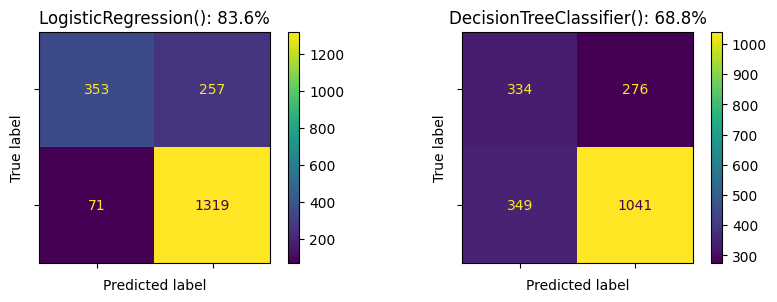

In [36]:
from sklearn import metrics
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

model_list = [logreg, arbre]

fig, ax = plt.subplots(1, 2, figsize=(10,3))
for index, model in enumerate(model_list):
    model.fit(X_train_vecto, y_train) 
    ax[index].set_title(f"{model}: {model.score(X_test_vecto, y_test):.1%}")
    y_pred = model.predict(X_test_vecto)
    metrics.ConfusionMatrixDisplay(
            confusion_matrix=metrics.confusion_matrix(y_test, y_pred),
            display_labels=['', '']).plot(ax=ax[index])

## Optionnel: algorithme `json` et manipulation.
Il s'agit d'un fichier JSON contenant plusieurs clés.
Chaque clé a une valeur, qui pourrait potentiellement être une autre clé, contenant une autre valeur, qui pourrait potentiellement être une autre clé, etc.

In [37]:
food = {
  "clé1": {
    "fruit1": "pomme",
    "légume4": "brocoli"
  },
  "clé2": {
    "légume1": "carotte",
    "fruit5": "banane",
    "légume3": "courgette"
  },
  "clé3": {
    "niveau1": {
      "niveau2": {
        "fruit3": "orange",
        "légume5": "aubergine",
        "fruit5": "mangue"
      }
    }
  },
  "clé4": {
    "niveau1": {
      "niveau2": {
        "niveau3": {
          "fruit6": "raisin",
          "fruit7": "fraise",
          "légume4": "poivron",
          "fruit2": "pastèque"
        }
      }
    }
  }
}


Problème:
Les fruits et légumes ont été égarés dans ce fichier JSON.L'objectif est de récupérer chacun des fruits et légumes et de les attribuer à deux listes correspondantes: `Fruits_list` &` LEGETALS_LIST`.

Solution attendue:

`fruits_list` = `['pomme', 'banane', 'orange', 'mangue', 'raisin', 'fraise', 'pastèque']`

`vegetables_list` = `['brocoli', 'carotte', 'courgette', 'aubergine', 'poivron']`


In [38]:
fruits_list = []
vegetables_list = []


def parcourir(noeud):
    #Parcourt récursivement le dictionnaire et trie fruits / légumes
    for cle, valeur in noeud.items():
        if isinstance(valeur, dict):
            parcourir(valeur)            # sous-dictionnaire -> on descend
        elif "fruit" in cle:
            fruits_list.append(valeur)
        elif "légume" in cle:
            vegetables_list.append(valeur)


parcourir(food)
print("fruits_list =", fruits_list)
print("vegetables_list =", vegetables_list)

fruits_list = ['pomme', 'banane', 'orange', 'mangue', 'raisin', 'fraise', 'pastèque']
vegetables_list = ['brocoli', 'carotte', 'courgette', 'aubergine', 'poivron']


Ensuite, vous créerai un nouveau dictionnaire, qui contiendra simplement deux clés: «fruits» et «légumes».Chaque clé aura la valeur de la liste des fruits et la liste des légumes.De cette façon, tout sera en ordre.

Solution attendue:

`food_dict` = `{'fruits': ['pomme','banane','orange','mangue','raisin','fraise','pastèque'],
 'legumes': ['brocoli', 'carotte', 'courgette', 'aubergine', 'poivron']}`

In [39]:
food_dict = {"fruits": fruits_list, "legumes": vegetables_list}
food_dict

{'fruits': ['pomme',
  'banane',
  'orange',
  'mangue',
  'raisin',
  'fraise',
  'pastèque'],
 'legumes': ['brocoli', 'carotte', 'courgette', 'aubergine', 'poivron']}